# Fobench Basics
Welcome to the tutorial of the basic functionalities of Fobench. This notebook will guide you through the loading of data, preprocessing steps and visuals.


In [16]:
import sys
sys.path.append('/home/joni/Dokumente/GEO4D/Software/fobench/')
from fobench.fiber import Fiber

The workhorse of Fobench is the `Fiber` class, it contains the actual fiber optic record and provides a lot of functionality to manipulate data in space and time. Let us go right ahead and load a file. We simply give the path to the file and we let Fobench know the manufacturer of the interrogator we used.

In [17]:
das = Fiber('./example_data/2024_07_11_05h15m16s_HDAS_2DRawData_Strain.h5', 'aragon')

Reading HDF5 file (Aragon Photonics Format)...


The following manufacturers are supported in Fobench:

    - 'tmds' from 'silixa'
    - 'hdf5' from 'silixa'
    - 'hdf5' from 'febus'
    - 'hfd5' from 'tera15'
    - 'hdf5' from 'asn'
    - 'hdf5' from 'quantx'

First, we will have a look at the most important aquisition parameters of our file:

In [18]:
print(das)
#das.metadata() # for the full metadata


Instance of Fiber class
recording parameters:
-----------------------------------------------------------------
units                     = strain
start_time                = 2024-07-11T05:15:15.791536Z
end_time                  = 2024-07-11T05:16:15.791536Z
total_channels            = 501
spatial_interval          = 1.0
sampling_frequency        = 250.0
gauge_length              = 6.0


We can see that the file contains only a single minute of strain data, lets concatenate a second file and convert into strain-rate. 

In [19]:
das += Fiber('./example_data/2024_07_11_05h16m16s_HDAS_2DRawData_Strain.h5', 'aragon') # the += syntax just calls Fiber.concatenate
das.differentiate()

Reading HDF5 file (Aragon Photonics Format)...


Our original sampling frequency is a bit too high, we will go down to 50 Hz. 

If we then check the aquisition parameters again, we can see that we now have two minutes of strain-rate data at 50 Hz

In [20]:
das.decimate(50)
print(das)


Instance of Fiber class
recording parameters:
-----------------------------------------------------------------
units                     = strain-rate
start_time                = 2024-07-11T05:15:15.791536Z
end_time                  = 2024-07-11T05:17:15.791002Z
total_channels            = 501
spatial_interval          = 1.0
sampling_frequency        = 50.0
gauge_length              = 6.0


The `Fiber` class stores the actual data in `Fiber.data` attribute. This way we can easily access and extract it:

In [21]:
das.data

array([[-5.05701593e-07, -4.43409428e-07, -3.89642319e-07, ...,
        -2.66172304e-09,  2.66216876e-07,  4.95154280e-08],
       [ 6.54711691e-07,  6.16109753e-07,  1.00522968e-06, ...,
        -8.24444780e-08, -1.81719877e-08, -1.63707361e-07],
       [-4.14687086e-07, -4.66523376e-07,  8.97711739e-07, ...,
        -5.69622756e-08, -1.25831108e-07,  2.40222577e-08],
       ...,
       [-6.69255165e-09, -1.69031062e-07, -1.09115180e-07, ...,
        -1.13536034e-08,  3.56308949e-09, -1.68962164e-08],
       [ 8.82228047e-08,  4.73564115e-08,  1.20374217e-07, ...,
         7.79522659e-08,  1.10855586e-07,  1.05575880e-07],
       [-1.81449385e-08,  1.28641489e-07,  5.04923928e-08, ...,
        -6.19960596e-08, -1.32071017e-07, -6.94855845e-08]])

Most operations on the data are done inplace. Just in case we mess something up later on, at any point we can get a copy of the records current state with `Fiber.copy`

In [22]:
backup_das = das.copy()

Before we have a look at the data, we should apply some basic preprocessing. Let us start with a simple bandpass filter between 0.1 and 50 Hz. We can check if the filter was applied successfully by looking at the list stored in `Fiber.processing`:

In [23]:
das.filter(f_type='bandpass', freq=(0.1, 20)) # other filter options are highpass, lowpass and bandstop. Fobench also provides more specialized filters such as Cheby and FIR-filters
das.processing

[{'instance creation': 'Mon Nov 18 09:56:09 2024'},
 {'differentiate': {'method': 'gradient', 'dim': 't'}},
 {'decimate': {'new_freq': 50, 'ftype': 'fir-remez'}},
 {'detrend': {'order': 1, 'dim': 't'}},
 {'demean': {'dim': 't'}},
 {'taper': {'frac': 0.05, 'dim': 't'}},
 {'filter': {'f_type': 'bandpass',
   'freq': (0.1, 20),
   'pre_process': True,
   'frac': 0.05,
   'order': 1,
   'options': {}}}]

The list keeps track of all preprocessing steps included in Fobench so that at any point we can go back and check which steps we took in what order. This is done by storing the methods name and all parameters it is called with.

We can see that before bandpass filtering the data was detrended, demeaned and tapered. That is because the filter function by default conviniently performs these steps by calling `Fiber.detrend`, `Fiber.demean` and `Fiber.taper` before the actual filtering. Of course all these methods can be used individually and `filter` can be used with the `pre_process` parameter set to `False`.

Note also that most methods have additional parameters such as the removal of higher order polynomial trends by passing the `order` to `Fiber.detrend`. A lot of methods can be applied in both space and time, this is determined by the `dim` parameter.


Now back to our data! Let us plot the record in both time and frequency domain:

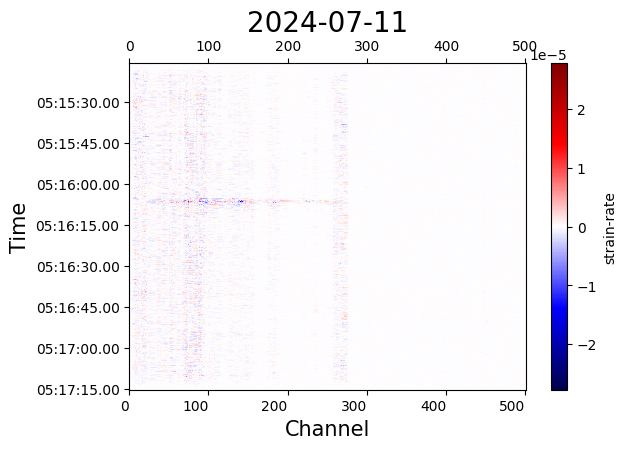

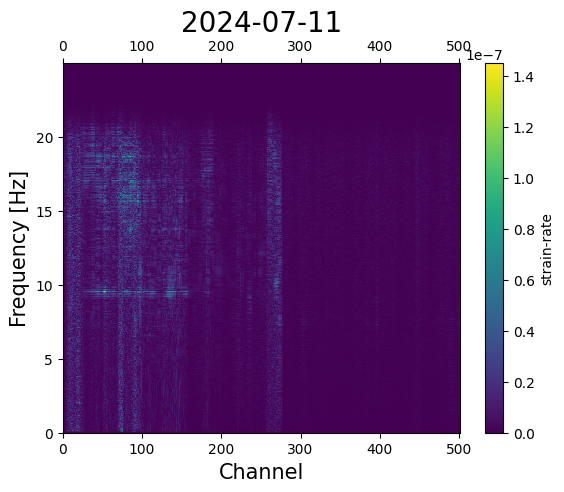

In [24]:
das.plot()
das.spectrogram()

It seems that we have recorded a small event! However it looks like towards the end of the cable we have no useful data anymore. We will trim the record in space and time and focus on the channels 20 to 280 and the time shortly before and after the event.

In [25]:
das.restrict_channels((20, 280))
das.total_channels # number of channels in the record
# print(das.channels_num) # all channel numbers

261

Now that we have indentified the channels that we are interested in, the next time when we are loading data, we can retrieve only the part of interest. This can decrease the loading time significantly. We do that by simply passing the channel range to the Fiber class: 
```
file = './example_data/2024_07_11_05h15m16s_HDAS_2DRawData_Strain.h5'
manufacturer = 'aragon'
channels = [20, 280]
das = Fiber(file, manufacturer, range_ch=channels)
```
We can also trim the record around the time of the event and normalize to the absolute max of the record before plotting:

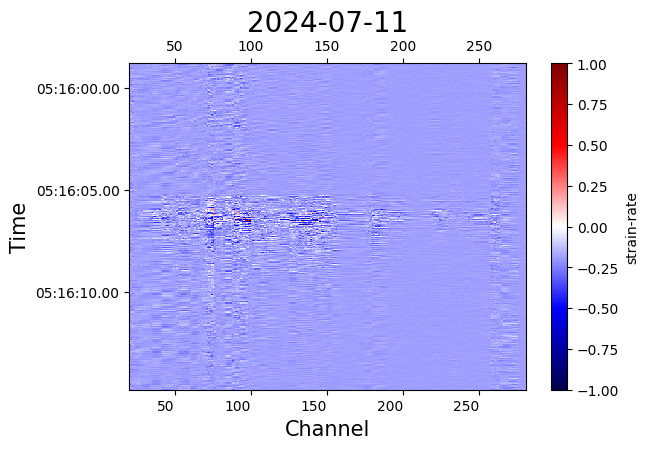

In [26]:
t0 = das.start_time + 43
tf = t0 + 16
das.trim(t0, tf)
das.normalize() #default is abolute max normalization, other options are trace max, running absolute mean and 1bit
das.plot()

We can look at a few channels in more detail, lets go for 100 - 110:

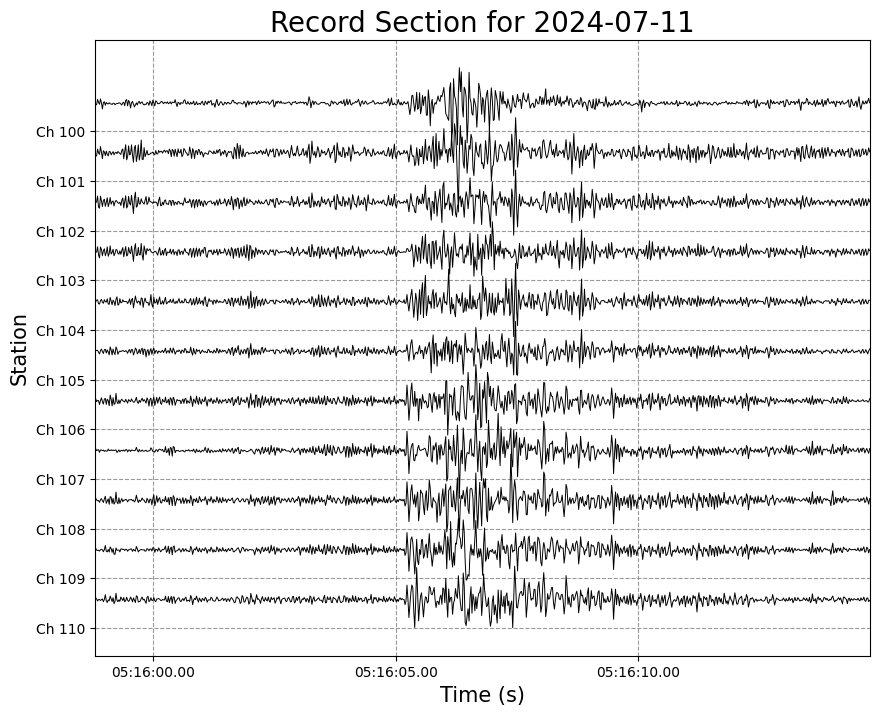

In [27]:
das.plot_record_section((100, 110))

We can plot a single channel again both in space and time:

85


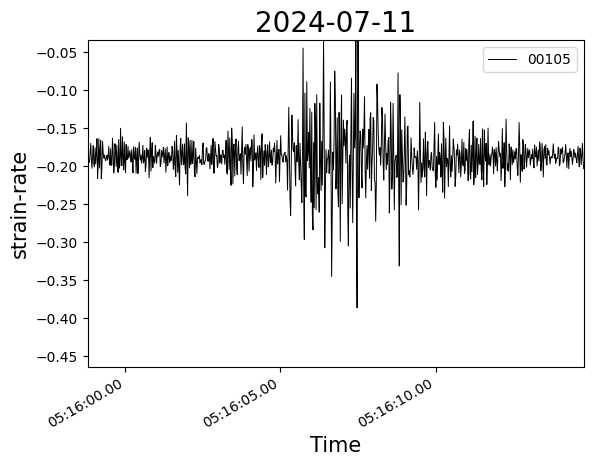

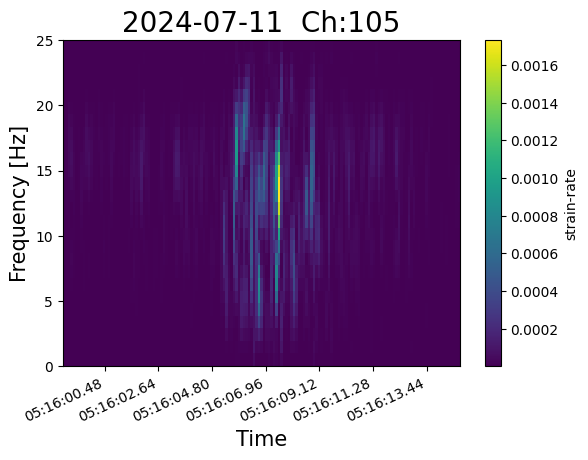

In [28]:
ch = 105
das.channel_plot(ch)
das.channel_spectrogram(ch)